In [1]:
import os
import random
import string
from collections import Counter, defaultdict
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils as nn_utils
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models
import json


In [2]:
# Define paths
coco_path = '/kaggle/input/coco-2017-dataset/coco2017'
images_path = os.path.join(coco_path, "")
annotations_path = os.path.join(coco_path, 'annotations')

train_images_path = os.path.join(images_path, 'train2017')
val_images_path = os.path.join(images_path, 'val2017')
test_images_path = os.path.join(images_path, 'test2017')

train_annotations_file = os.path.join(annotations_path, 'captions_train2017.json')
val_annotations_file = os.path.join(annotations_path, 'captions_val2017.json')


In [3]:
def load_captions(annotations_file):
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)
    captions = defaultdict(list)
    for ann in annotations['annotations']:
        image_id = ann['image_id']
        caption = ann['caption']
        image_file = f'{image_id:012d}.jpg'
        captions[image_file].append(caption)
    return captions

train_captions = load_captions(train_annotations_file)
val_captions = load_captions(val_annotations_file)

In [4]:
print(len(train_captions))

118287


In [5]:
def clean_caption(caption):
    caption = caption.translate(str.maketrans('', '', string.punctuation))
    caption = ' '.join([word for word in caption.split() if len(word) > 1 and not any(char.isdigit() for char in word)])
    caption = caption.lower()
    return caption

# Clean captions
for image in train_captions:
    train_captions[image] = [clean_caption(caption) for caption in train_captions[image]]

for image in val_captions:
    val_captions[image] = [clean_caption(caption) for caption in val_captions[image]]

In [6]:
# Data augmentation pipeline
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Lambda(lambda x: x[:3, :, :]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.Lambda(lambda x: x[:3, :, :]),
])


In [7]:
def load_image(image_file, transform):
    image = Image.open(image_file).convert('RGB')
    image = transform(image)
    return image

# Load image function helper
def load_val_image(image_file):
    image = Image.open(image_file).convert('RGB')
    image = val_transform(image)
    return image

In [8]:
word_counter = Counter()
for image, caption_list in train_captions.items():
    for caption in caption_list:
        word_counter.update(caption.split())

vocab_threshold = 5
vocab = [word for word, count in word_counter.items() if count > vocab_threshold]
vocab_size = len(vocab) + 4

# stoi and itos dictionaries for encoding and decoding
stoi = {word: idx + 4 for idx, word in enumerate(vocab)}
stoi['<PAD>'] = 0
stoi['<START>'] = 1
stoi['<END>'] = 2
stoi['<UNK>'] = 3
itos = {idx: word for word, idx in stoi.items()}

In [9]:
len(vocab)

9346

In [10]:
# Helper functions
def encode_caption(caption):
    # Default entry for dictionary.get()
    encoded = [stoi['<START>']] + [stoi.get(word, stoi['<UNK>']) for word in caption.split()] + [stoi['<END>']]
    return encoded

def decode_caption(encoded_caption):
    # Default entry for dictionary.get()
    return ' '.join([itos.get(idx, '<UNK>') for idx in encoded_caption])

def pad_caption(caption, max_length):
    # This actually pads one less than the max, which is not intended. But, we will keep this anyways
    return caption + [stoi['<PAD>']] * (max_length - len(caption))

In [11]:
max_length = max(len(caption.split()) for caption_list in train_captions.values() for caption in caption_list) + 2
max_length

49

In [12]:
# Encodes and pads captions
encoded_train_captions = defaultdict(list)
for image in train_captions:
    for caption in train_captions[image]:
        encoded = encode_caption(caption)
        padded = pad_caption(encoded, max_length)
        encoded_train_captions[image].append(padded)

encoded_val_captions = defaultdict(list)
for image in val_captions:
    for caption in val_captions[image]:
        encoded = encode_caption(caption)
        padded = pad_caption(encoded, max_length)
        encoded_val_captions[image].append(padded)


In [13]:
def create_sequences(encoded_caption):
    input_sequence = encoded_caption[:-1]
    target_sequence = encoded_caption[1:]
    return input_sequence, target_sequence

# Creates target and train sequences, corresponding to each image, per image
input_train_sequences = defaultdict(list)
target_train_sequences = defaultdict(list)
for image, caption_list in encoded_train_captions.items():
    for caption in caption_list:
        input_seq, target_seq = create_sequences(caption)
        input_train_sequences[image].append(input_seq)
        target_train_sequences[image].append(target_seq)

input_val_sequences = defaultdict(list)
target_val_sequences = defaultdict(list)
for image, caption_list in encoded_val_captions.items():
    for caption in caption_list:
        input_seq, target_seq = create_sequences(caption)
        input_val_sequences[image].append(input_seq)
        target_val_sequences[image].append(target_seq)


In [14]:
def create_batch(caption_dict, input_seq_dict, target_seq_dict, batch_size, image_keys, path):
    images_batch = []
    input_captions_batch = []
    target_captions_batch = []

    for image in image_keys[:batch_size]:
        selected_caption_idx = random.randint(0, len(caption_dict[image]) - 1)
        input_captions_batch.append(input_seq_dict[image][selected_caption_idx])
        target_captions_batch.append(target_seq_dict[image][selected_caption_idx])
        image_path = os.path.join(path, image)  # Adjust this path accordingly
        images_batch.append(load_image(image_path, transform))

    images_batch = torch.stack(images_batch)
    input_captions_batch = torch.tensor(input_captions_batch)
    target_captions_batch = torch.tensor(target_captions_batch)

    return images_batch, input_captions_batch, target_captions_batch

batch_size = 4
train_keys = list(train_captions.keys())
val_keys = list(val_captions.keys())

# Example usage
train_image_batch, train_caption_batch, train_label_batch = create_batch(train_captions, input_train_sequences, target_train_sequences, batch_size, train_keys, train_images_path)
val_image_batch, val_caption_batch, val_label_batch = create_batch(val_captions, input_val_sequences, target_val_sequences, batch_size, val_keys, val_images_path)


Training example:


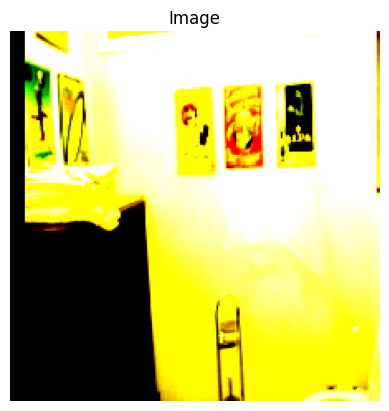

Input Caption: <START> room with toilet dresser and wall hangings <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Target Caption: room with toilet dresser and wall hangings <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Validation example:


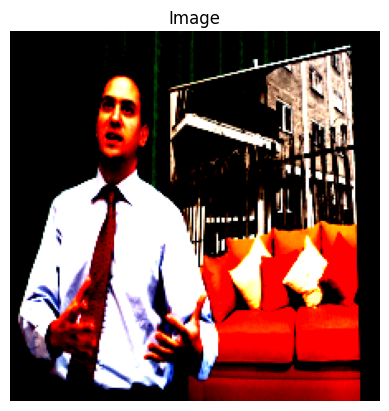

Input Caption: <START> man is standing talking in front of picture <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Target Caption: man is standing talking in front of picture <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


In [15]:
def visualize_example(caption_dict, input_seq_dict, target_seq_dict, transform, path):
    random_image = random.choice(list(caption_dict.keys()))
    caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)

    image_path = os.path.join(path, random_image)  # Adjust this path accordingly
    image_tensor = load_image(image_path, transform)
    image_array = image_tensor.permute(1, 2, 0).numpy()

    input_caption_encoded = input_seq_dict[random_image][caption_idx]
    target_caption_encoded = target_seq_dict[random_image][caption_idx]
    input_caption = decode_caption(input_caption_encoded)
    target_caption = decode_caption(target_caption_encoded)

    plt.imshow(image_array)
    plt.axis('off')
    plt.title('Image')
    plt.show()

    print(f"Input Caption: {input_caption}")
    print(f"Target Caption: {target_caption}")

print("Training example:")
visualize_example(train_captions, input_train_sequences, target_train_sequences, transform, train_images_path)

print("Validation example:")
visualize_example(val_captions, input_val_sequences, target_val_sequences, val_transform, val_images_path)


In [16]:
# Define a residual block for MLP architecture
class ResBlockMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(ResBlockMLP, self).__init__()
        
        self.norm1 = nn.LayerNorm(input_size)
        self.fc1 = nn.Linear(input_size, input_size//2)
        self.norm2 = nn.LayerNorm(input_size//2)
        self.fc2 = nn.Linear(input_size//2, output_size)
        self.fc3 = nn.Linear(input_size, output_size)
        self.act = nn.ELU()

    def forward(self, x):
        x = self.act(self.norm1(x))
        skip = self.fc3(x)
        x = self.act(self.norm2(self.fc1(x)))
        x = self.fc2(x)
        return x + skip

In [17]:
class ConvNet(nn.Module):
    def __init__(self, dropout):
        super(ConvNet, self).__init__()
        
        # Load the pretrained VGG16 model
        self.vgg16 = models.vgg16(pretrained=True)
        
        # Freeze all the VGG16 layers except the last fully connected layer
        for param in self.vgg16.parameters():
            param.requires_grad = False
        for param in self.vgg16.classifier.parameters():
            param.requires_grad = True
        
        # Add dropout before the final fully connected layer
        self.vgg16.classifier[-1] = nn.Sequential(
            nn.Dropout(dropout),
            self.vgg16.classifier[-1]
        )
    
    def forward(self, inputs):  # (224, 224, 3)
        out = self.vgg16(inputs)
        return out  # (B, 1000)


In [18]:
class Decoder(nn.Module):
    def __init__(self, channels_in, dropout, vocab_size, emb_size, hidden_size, num_layers, num_blocks):
        super(Decoder, self).__init__()
        
        self.convnet = ConvNet(dropout = dropout)

        self.linear = nn.Linear(1000, hidden_size)
        
        self.embedding = nn.Embedding(vocab_size, emb_size)
        
        # Define LSTM layer
        self.lstm = nn.LSTM(input_size = emb_size, hidden_size = hidden_size, num_layers = num_layers, bias = False, batch_first = True)

        # Residual blocks
        self.blocks = nn.Sequential(*[ResBlockMLP(hidden_size, hidden_size) for _ in range(num_blocks)])

        # Activation function
        self.act = nn.ELU()
        
        # Define the output fully connected layer
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    # Memory in will always be a matrice of zeros
    def forward(self, images, captions, mem_in):

        features = self.convnet(images) # (B, 4096)
        features = self.linear(features) # (B, hidden_size)
        features = features.unsqueeze(0).repeat(self.lstm.num_layers, 1, 1) # (num_layers, B, hidden_size)

        batch_size = images.size(0)
        hidden_size = self.lstm.hidden_size
        num_layers = self.lstm.num_layers

        captions = self.embedding(captions)
        
        outputs, (hidden_out, mem_out) = self.lstm(captions, (features, mem_in))
        # x = (B, T, emb_size)
        # hidden_out = (num_layers, B, hidden_size)
        # mem_out = (num_layers, B, hidden_size)

        outputs = self.act(self.blocks(outputs))
        
        return self.fc_out(outputs) 

In [19]:
#### UPDATE the model parameters here

device = torch.device(0 if torch.cuda.is_available() else 'cpu')

nepochs = 10

learning_rate = 1e-4

channels_in = 3

dropout = 0.5

vocab_size = len(stoi)

emb_size = 512

hidden_size = 2048

# LSTM layers
num_layers = 2

# ResBlocks
num_blocks = 2

batch_size = 256

max_length = max_length

# Padding 1 less, than the max_length
time_steps = max_length - 1

max_grad_norm = 5.0  # Gradient clipping threshold

In [20]:
model = Decoder(channels_in = channels_in, dropout = dropout, vocab_size = vocab_size, emb_size = emb_size, hidden_size = hidden_size, num_layers = num_layers, num_blocks = num_blocks).to(device)

memory = torch.zeros(num_layers, batch_size, hidden_size, device=device)

optimizer = optim.AdamW([
    {'params': model.linear.parameters()},
    {'params': model.embedding.parameters()},
    {'params': model.lstm.parameters()},
    {'params': model.blocks.parameters()},
    {'params': model.fc_out.parameters()}
], lr=learning_rate, weight_decay=1e-4)

lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nepochs, eta_min=0)

loss_fn = nn.CrossEntropyLoss()

training_loss = []

val_loss = []

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [21]:
# Calculate number of model parameters
num_model_params = 0
for param in model.parameters():
    num_model_params += param.flatten().shape[0]

print("This model Has %d Parameters, %d Million" % (num_model_params, num_model_params//1e6 ) )

# 154M
# 163M

This model Has 235678638 Parameters, 235 Million


In [4]:
nepochs = 20

In [22]:
def calculate_average_val_loss(model, val_captions, val_input_sequences, val_target_sequences, batch_size, loss_fn):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    # Calculate the number of complete batches
    num_complete_batches = len(val_keys) // batch_size
    
    with torch.no_grad():
        for i in range(0, num_complete_batches * batch_size, batch_size):
            batch_keys = val_keys[i:i+batch_size]
            image_batch, caption_batch, label_batch = create_batch(val_captions, input_val_sequences, target_val_sequences, len(batch_keys), batch_keys, val_images_path)
            
            image_batch = image_batch.to(device)
            caption_batch = caption_batch.to(device)
            label_batch = label_batch.to(device)
            
            outputs = model(image_batch, caption_batch, memory)
            outputs = outputs.reshape(-1, vocab_size)
            label_batch = label_batch.reshape(-1)
            
            loss = loss_fn(outputs, label_batch)
            total_loss += loss.item()
            num_batches += 1
    
    average_loss = total_loss / num_batches if num_batches > 0 else float('inf')
    return average_loss

In [ ]:
# Training loop
for epoch in range(nepochs):
    print("Training:")
    
    # Shuffle the dataset at the beginning of each epoch (to ensure that for every epoch, the batches created are randomized)
    # We train over epochs to ensure that all data in the training_set is trained over
    random.shuffle(train_keys)
    
    # Training
    model.train()
    epoch_loss = 0
    num_batches = 0

    # Variables to accumulate loss for intervals
    interval_loss = 0
    interval_batches = 0
    print_interval = 30  # Adjust the interval as needed

    # This loop ensures that we always get a batch of batch_size number of elements, and iterate over all examples generated in the batch
    # In every iteration, we augment the image keys to reduce overfitting
    # Calculate the number of complete batches
    num_complete_batches = len(train_keys) // batch_size
    
    for i in range(0, num_complete_batches * batch_size, batch_size):
        batch_keys = train_keys[i:i+batch_size]
        image_batch, caption_batch, label_batch = create_batch(train_captions, input_train_sequences, target_train_sequences, len(batch_keys), batch_keys, train_images_path)

        image_batch = image_batch.to(device)
        caption_batch = caption_batch.to(device)
        label_batch = label_batch.to(device)
        
        outputs = model(image_batch, caption_batch, memory)
        outputs = outputs.reshape(-1, vocab_size)
        label_batch = label_batch.reshape(-1)
        
        loss = loss_fn(outputs, label_batch)
        epoch_loss += loss.item()
        interval_loss += loss.item()
        num_batches += 1
        interval_batches += 1

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Clip gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        
        # Print average loss every 'print_interval' batches
        if interval_batches == print_interval:
            avg_interval_loss = interval_loss / interval_batches
            print(f"Epoch {epoch+1}, Batch {i//batch_size+1}/{num_complete_batches}, AVG Interval Loss: {avg_interval_loss:.4f}")
            interval_loss = 0
            interval_batches = 0

    # Calculate average training loss for the epoch
    avg_train_loss = epoch_loss / num_batches
    training_loss.append(avg_train_loss)

    # Validation
    model.eval()
    print("Evaluating:")
    
    val_epoch_loss = calculate_average_val_loss(model, val_captions, input_val_sequences, target_val_sequences, batch_size, loss_fn)
    val_loss.append(val_epoch_loss)

    # Print epoch results
    print(f"Epoch {epoch+1}/{nepochs}, AVG Train Loss: {avg_train_loss:.4f}, AVG Val Loss: {val_epoch_loss:.4f}")

    # Update learning rate
    lr_scheduler.step()

Training:
Epoch 1, Batch 30/462, AVG Interval Loss: 0.5397
Epoch 1, Batch 60/462, AVG Interval Loss: 0.5400
Epoch 1, Batch 90/462, AVG Interval Loss: 0.5448
Epoch 1, Batch 120/462, AVG Interval Loss: 0.5462
Epoch 1, Batch 150/462, AVG Interval Loss: 0.5417
Epoch 1, Batch 180/462, AVG Interval Loss: 0.5414
Epoch 1, Batch 210/462, AVG Interval Loss: 0.5385
Epoch 1, Batch 240/462, AVG Interval Loss: 0.5441
Epoch 1, Batch 270/462, AVG Interval Loss: 0.5383
Epoch 1, Batch 300/462, AVG Interval Loss: 0.5421


In [ ]:
# Save the entire model
torch.save(model, '30-lstm-coco2017-image-captioning.pth')


In [ ]:
import torch
from IPython.display import FileLink

# Save your .pth file
model_path = 'final-30-lstm-coco2017-image-captioning.pth'
torch.save(model.state_dict(), model_path)

# Create a download link
display(FileLink(model_path))

----
----
----
----
----
Random Image: 000000234779.jpg


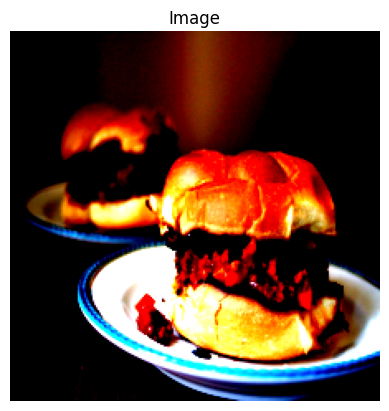

Original Caption: <START> two sloppy joe sandwiches on two separate plates <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: sandwich eggs fries potatoes ketchup strawberries and butter <END>
BLEU-1 Score: 0.0015
BLEU-4 Score: 0.0003
Generated Caption: burger is kept on bun <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: sandwich with pickles and lettuce on it <END>
BLEU-1 Score: 0.0017
BLEU-4 Score: 0.0002
Generated Caption: sandwich on plate <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: breakfast breakfast sandwich with bacon kiwi bread syrup butter sprouts tips spear <END>
BLEU-1 Score: 0.0052
BLEU-4 Score: 0.0011
Random Image: 000000170955.jpg


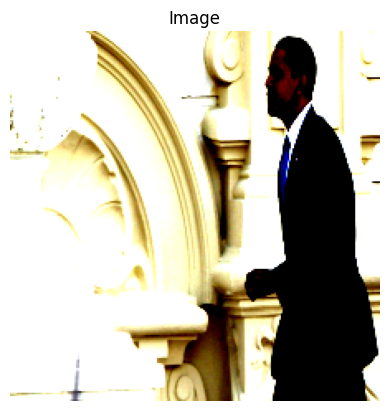

Original Caption: <START> president barack obama walking near white building <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: bride sitting in bathroom <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: woman posing for photo <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: man with polka dot tie <END>
BLEU-1 Score: 0.0002
BLEU-4 Score: 0.0000
Generated Caption: wedding woman standing together <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: bath tub in bathroom <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Random Image: 000000344100.jpg


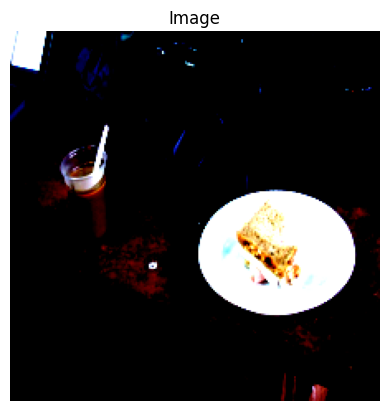

Original Caption: <START> table has camera cup and plate with sandwich on it <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: sandwich served into cafeteria bread <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: steak cook meal arranged in blender <END>
BLEU-1 Score: 0.0004
BLEU-4 Score: 0.0001
Generated Caption: some desserts sitting around table <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: decorated cake displayed in restaurant kitchen <END>
BLEU-1 Score: 0.0004
BLEU-4 Score: 0.0001
Generated Caption: some pizzas on table <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Random Image: 000000118921.jpg


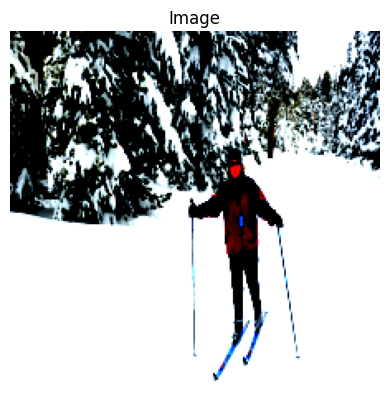

Original Caption: <START> woman is wearing pink and black jacket is sking <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: woman posing in the snow <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: person skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: group of skiers trekking through the woods <END>
BLEU-1 Score: 0.0008
BLEU-4 Score: 0.0002
Generated Caption: guy skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: person skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Random Image: 000000574810.jpg


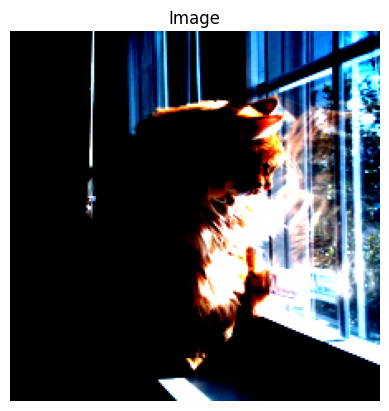

Original Caption: <START> an orange cat perched in window watching outside <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: cat stares into fridge <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Generated Caption: cat sitting inside of suitcase <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: cat inside suitcase <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: cat lying on chair <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Generated Caption: cat sitting inside of suitcase <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000


In [25]:
# Sampling functions with BLEU scores only
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def sample_caption(image, max_length=30):
    model.eval()
    
    sos_token = torch.tensor([[stoi['<START>'], stoi['picture'], stoi['of']]], device=device)
    
    features = model.convnet(image.unsqueeze(0).to(device))  # Get features from the image
    features = model.linear(features)  # Transform features to hidden size
    features = features.unsqueeze(0).repeat(num_layers, 1, 1)  # Add time dimension (1, 1, hidden_size)
    
    input_tokens = sos_token  # Start with <sos> token
    generated_caption = []
    
    for _ in range(max_length):
        input_embed = model.embedding(input_tokens)  # Embed the input tokens
        
        output, _ = model.lstm(input_embed, (features, torch.zeros_like(features)))
        
        output = model.blocks(output)
        
        output = model.fc_out(output)  # Output shape: (1, seq_length, vocab_size)
        
        probabilities = F.softmax(output[:, -1, :], dim=-1)
        
        next_token = torch.argmax(probabilities, dim=-1).unsqueeze(0)
        next_token = torch.multinomial(probabilities, num_samples=1)
        
        generated_caption.append(itos[next_token.item()])
        
        input_tokens = torch.cat([input_tokens, next_token], dim=1)

        if next_token.item() == stoi['<END>'] or next_token.item() == stoi['<PAD>']:
            break
    
    return generated_caption

def visualize_example(caption_dict, input_seq_dict, target_seq_dict, max_length, path):
    random_image = random.choice(list(caption_dict.keys()))
    caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)
    image_path = os.path.join(path, random_image)

    image_tensor = load_image(image_path, val_transform)
    image_array = image_tensor.permute(1, 2, 0).numpy()

    print(f"Random Image: {random_image}")
    
    plt.imshow(image_array)
    plt.axis('off')
    plt.title('Image')
    plt.show()

    original_caption_encoded = input_seq_dict[random_image][caption_idx]
    original_caption = decode_caption(original_caption_encoded)
    print(f"Original Caption: {original_caption}")

    references = [original_caption.split()]  # Tokenized reference caption
    smoothing_function = SmoothingFunction().method1

    for _ in range(5):
        generated_caption = sample_caption(image_tensor, max_length)
        print(f"Generated Caption: {' '.join(generated_caption)}")

        # Calculate BLEU-1 and BLEU-4 scores
        bleu_1 = sentence_bleu(references, generated_caption, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
        bleu_4 = sentence_bleu(references, generated_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)

        print(f"BLEU-1 Score: {bleu_1:.4f}")
        print(f"BLEU-4 Score: {bleu_4:.4f}")

# Example usage
num_samples = 5
# for _ in range(num_samples):
#     visualize_example(test_captions, input_test_sequences, target_test_sequences, max_length, test_images_path)
print("----")
print("----")
print("----")
print("----")
print("----")
for _ in range(num_samples):
    visualize_example(val_captions, input_val_sequences, target_val_sequences, max_length, val_images_path)

In [6]:
!pip install --upgrade nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
      Successfully uninstalled nltk-3.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.8.1 which is incompatible.


In [4]:
!pip install git+https://github.com/salaniz/pycocoevalcap
!pip install nltk
!pip install matplotlib

  Cloning https://github.com/salaniz/pycocoevalcap to /tmp/pip-req-build-qy2ljwtp
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap /tmp/pip-req-build-qy2ljwtp
  Resolved https://github.com/salaniz/pycocoevalcap to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.8/427.8 kB 8.0 MB/s eta 0:00:00ta 0:00:01
  Created wheel for pycocoevalcap: filename=pycocoevalcap-1.2-py3-none-any.whl size=104312245 sha256=059c354f8b6864af4fd4659bf9408836bad6f6751534f10cbb265a4c06aff918
  Stored in directory: /tmp/pip-ephem-wheel-cache-v_1wiicp/wheels/43/54/73/3e2c6d4ace7657958cde52ac6fd47b342cd4aae5a7aa4fcbf9
Successfully built pycocoevalcap


In [19]:
pip install git+https://github.com/salaniz/pycocoevalcap

  Cloning https://github.com/salaniz/pycocoevalcap to /tmp/pip-req-build-lkeeryq1
  Running command git clone --filter=blob:none --quiet https://github.com/salaniz/pycocoevalcap /tmp/pip-req-build-lkeeryq1
  Resolved https://github.com/salaniz/pycocoevalcap to commit a24f74c408c918f1f4ec34e9514bc8a76ce41ffd
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [15]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [72]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 39.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


Random Image: 000000377946.jpg


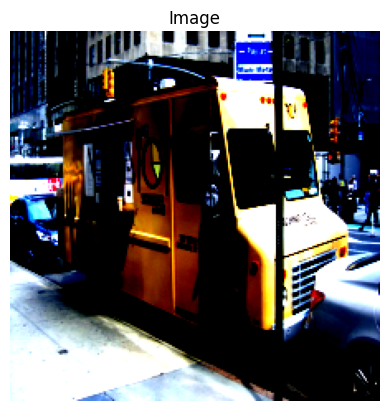

Original Caption: <START> food tuck parallel parked along street <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Reference Caption 1: yellow food truck parked close to car
Reference Caption 2: yellow box truck parked on busy street in city
Reference Caption 3: yellow food truck parked on the side of city street
Reference Caption 4: catering truck parked tightly between cars on city street
Reference Caption 5: food tuck parallel parked along street
Generated Caption: semitrailer bus painted by graffiti <END>
Max BLEU-1 Score: 0.00
Max BLEU-4 Score: 0.00
Max METEOR Score: 0.00
Max Semantic Similarity Score: 29.90%
Random Image: 000000127987.jpg


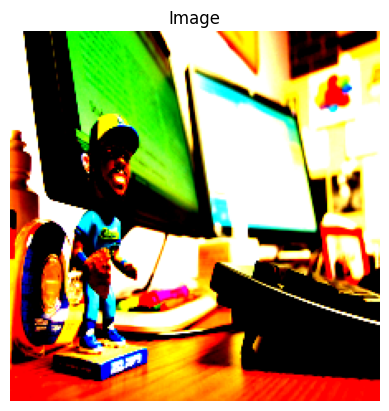

Original Caption: <START> <UNK> head is shown next to computer screens <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Reference Caption 1: baseball player bobble head next to two computer monitors on desk
Reference Caption 2: close of bobble head doll with computer in the background
Reference Caption 3: bobble head is shown next to computer screens
Reference Caption 4: bobble head baseball figurine on desk
Reference Caption 5: desk with two computer screens and cecil cooper bobble head
Generated Caption: man leaning over keyboard of laptop computer <END>
Max BLEU-1 Score: 19.47
Max BLEU-4 Score: 2.78
Max METEOR Score: 10.20
Max Semantic Similarity Score: 52.93%
Random Image: 000000462629.jpg


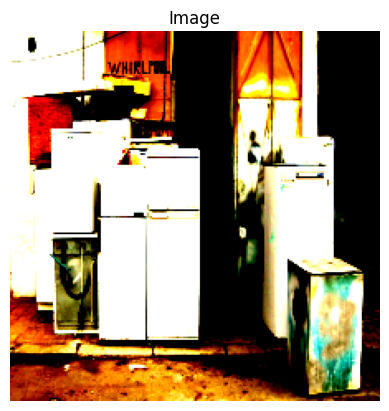

Original Caption: <START> number of vintage refrigerators and freezers sitting outdoors <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Reference Caption 1: number of vintage refrigerators and freezers sitting outdoors
Reference Caption 2: bunch of old refrigerators in front of an open door
Reference Caption 3: tall boxes are stacked on brown sidewalkoutside
Reference Caption 4: old appliances outside the back door of repair shop
Reference Caption 5: kitchen appliances outside building with yellow doors
Generated Caption: busted ironing toilet with its lid open <END>
Max BLEU-1 Score: 12.50
Max BLEU-4 Score: 2.78
Max METEOR Score: 7.04
Max Semantic Similarity Score: 53.62%
Random Image: 000000450686.jpg


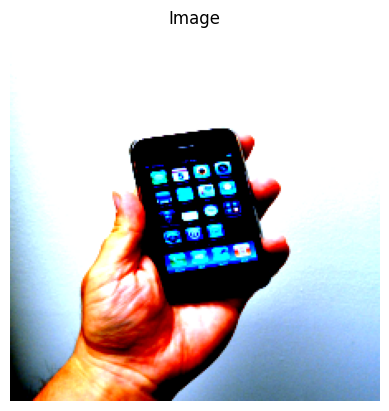

Original Caption: <START> hand holding smart phone with <UNK> on screen <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Reference Caption 1: hand holding smart phone with apps on screen
Reference Caption 2: persons hand holding up an active smartphone
Reference Caption 3: hand holds an iphone displaying various applications
Reference Caption 4: the hand is holding an iphone for the picture
Reference Caption 5: left hand holding onto black smart ohone
Generated Caption: several hand holding remote controls connected to technological tv <END>
Max BLEU-1 Score: 20.00
Max BLEU-4 Score: 4.46
Max METEOR Score: 25.68
Max Semantic Similarity Score: 59.52%
Random Image: 000000438862.jpg


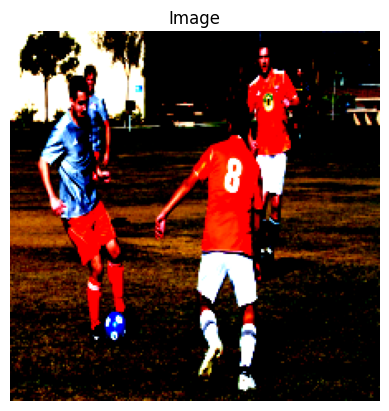

Original Caption: <START> several men are playing soccer on field <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Reference Caption 1: group of adults playing soccer on field
Reference Caption 2: the two teams are kicking soccer ball
Reference Caption 3: man kicking soccer ball during soccer game
Reference Caption 4: several men are playing soccer on field
Reference Caption 5: soccer players in orange and grey uniforms on field
Generated Caption: young boy playing soccer against each other during soccer match <END>
Max BLEU-1 Score: 27.27
Max BLEU-4 Score: 4.41
Max METEOR Score: 34.53
Max Semantic Similarity Score: 62.54%


In [85]:
import random
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import spacy  # Import spaCy for word embeddings

# Load spaCy model with word vectors
try:
    nlp = spacy.load('en_core_web_md')
except OSError:
    print("Downloading spaCy model...")
    !python -m spacy download en_core_web_md
    nlp = spacy.load('en_core_web_md')

def sample_caption(image, max_length=30):
    model.eval()
    
    sos_token = torch.tensor([[stoi['<START>']]], device=device)
    
    features = model.convnet(image.unsqueeze(0).to(device))  # Get features from the image
    features = model.linear(features)  # Transform features to hidden size
    features = features.unsqueeze(0).repeat(num_layers, 1, 1)  # Add time dimension (1, 1, hidden_size)
    
    input_tokens = sos_token  # Start with <sos> token
    generated_caption = []
    
    for _ in range(max_length):
        input_embed = model.embedding(input_tokens)  # Embed the input tokens
        
        output, _ = model.lstm(input_embed, (features, torch.zeros_like(features)))
        
        output = model.blocks(output)
        
        output = model.fc_out(output)  # Output shape: (1, seq_length, vocab_size)
        
        probabilities = F.softmax(output[:, -1, :], dim=-1)
        
        next_token = torch.multinomial(probabilities, num_samples=1)
        
        generated_caption.append(itos[next_token.item()])
        
        input_tokens = torch.cat([input_tokens, next_token], dim=1)

        if next_token.item() == stoi['<END>'] or next_token.item() == stoi['<PAD>']:
            break
    
    # Join generated caption tokens into a single string
    generated_caption_str = ' '.join(generated_caption)
    
    return generated_caption_str

def calculate_scores(references, generated_caption):
    # Function to calculate BLEU, METEOR, and optionally CIDEr, ROUGE scores
    smoothing_function = SmoothingFunction().method1
    
    # BLEU scores
    bleu_1_scores = []
    bleu_4_scores = []
    meteor_scores = []
    similarity_scores = []
    
    for reference in references:
        # Tokenize references and generated caption
        reference_tokenized = reference.split()
        generated_caption_tokenized = generated_caption.split()
        
        # BLEU scores
        bleu_1 = sentence_bleu([reference_tokenized], generated_caption_tokenized, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
        bleu_4 = sentence_bleu([reference_tokenized], generated_caption_tokenized, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)
        bleu_1_scores.append(bleu_1)
        bleu_4_scores.append(bleu_4)
        
        # METEOR score
        meteor = meteor_score([reference_tokenized], generated_caption_tokenized)
        meteor_scores.append(meteor)
        
        # Semantic similarity using spaCy word embeddings
        doc1 = nlp(reference)
        doc2 = nlp(generated_caption)
        similarity = doc1.similarity(doc2)
        similarity_scores.append(similarity)
    
    # Get maximum scores
    max_bleu_1 = max(bleu_1_scores) * 100
    max_bleu_4 = max(bleu_4_scores) * 100
    max_meteor = max(meteor_scores) * 100
    max_similarity = max(similarity_scores) * 100
    
    scores = {
        'Max BLEU-1': max_bleu_1,
        'Max BLEU-4': max_bleu_4,
        'Max METEOR': max_meteor,
        'Max Semantic Similarity': max_similarity
    }
    
    return scores

def visualize_example(caption_dict, input_seq_dict, target_seq_dict, max_length, path):
    random_image = random.choice(list(caption_dict.keys()))
    caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)
    image_path = os.path.join(path, random_image)

    image_tensor = load_image(image_path, val_transform)
    image_array = image_tensor.permute(1, 2, 0).numpy()

    print(f"Random Image: {random_image}")
    
    plt.imshow(image_array)
    plt.axis('off')
    plt.title('Image')
    plt.show()

    original_caption_encoded = input_seq_dict[random_image][caption_idx]
    original_caption = decode_caption(original_caption_encoded)
    if isinstance(original_caption, list):
        original_caption = ' '.join(original_caption)
    print(f"Original Caption: {original_caption}")

    references = caption_dict[random_image]  # Get all captions for the random image

    for i, reference in enumerate(references):
        print(f"Reference Caption {i+1}: {reference}")

    generated_caption = sample_caption(image_tensor, max_length)
    print(f"Generated Caption: {generated_caption}")

    # Calculate scores
    scores = calculate_scores(references, generated_caption)
    
    # Print max scores
    print(f"Max BLEU-1 Score: {scores['Max BLEU-1']:.2f}")
    print(f"Max BLEU-4 Score: {scores['Max BLEU-4']:.2f}")
    print(f"Max METEOR Score: {scores['Max METEOR']:.2f}")
    print(f"Max Semantic Similarity Score: {scores['Max Semantic Similarity']:.2f}%")

# Example usage
num_samples = 5
for _ in range(num_samples):
    visualize_example(val_captions, input_val_sequences, target_val_sequences, max_length, val_images_path)


In [ ]:
# Beam search implementation
import heapq

def beam_search_caption(model, image, beam_width=10, max_length=30):
    model.eval()
    
    sos_token = torch.tensor([[stoi['<START>']]], device=device)
    
    features = model.convnet(image.unsqueeze(0).to(device))  # Get features from the image
    features = model.linear(features)  # Transform features to hidden size
    features = features.unsqueeze(0).repeat(num_layers, 1, 1)  # Add time dimension (1, 1, hidden_size)
    
    # Initialize the beam
    beam = [(0, sos_token, features, torch.zeros_like(features), [])]
    
    for _ in range(max_length):
        candidates = []
        
        for cumulative_score, tokens, h, c, caption in beam:
            if caption and caption[-1] in [stoi['<END>'], stoi['<PAD>']]:
                candidates.append((cumulative_score, tokens, h, c, caption))
                continue
            
            input_embed = model.embedding(tokens)
            output, (h_n, c_n) = model.lstm(input_embed, (h, c))
            output = model.blocks(output)
            output = model.fc_out(output)
            
            probabilities = F.log_softmax(output[:, -1, :], dim=-1)
            top_scores, top_indices = probabilities.topk(beam_width)
            
            for score, idx in zip(top_scores.squeeze(), top_indices.squeeze()):
                new_tokens = torch.cat([tokens, idx.unsqueeze(0).unsqueeze(0)], dim=1)
                new_caption = caption + [idx.item()]
                new_cumulative_score = cumulative_score + score.item()
                candidates.append((new_cumulative_score, new_tokens, h_n, c_n, new_caption))
        
        # Select top beam_width candidates
        beam = heapq.nlargest(beam_width, candidates, key=lambda x: x[0])
        
        # Check if all beams have ended
        if all(caption[-1] in [stoi['<END>'], stoi['<PAD>']] for _, _, _, _, caption in beam):
            break
    
    # Return the caption with the highest score
    best_caption = max(beam, key=lambda x: x[0])[4]
    return [itos[token] for token in best_caption]

# Modify visualize_example to use beam_search_caption
def visualize_example(caption_dict, input_seq_dict, target_seq_dict, max_length, path):
    random_image = random.choice(list(caption_dict.keys()))
    caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)
    image_path = os.path.join(path, random_image)

    image_tensor = load_image(image_path, val_transform)
    image_array = image_tensor.permute(1, 2, 0).numpy()

    print(f"Random Image: {random_image}")
    
    plt.imshow(image_array)
    plt.axis('off')
    plt.title('Image')
    plt.show()
    
    original_caption_encoded = input_seq_dict[random_image][caption_idx]
    original_caption = decode_caption(original_caption_encoded)
    print(f"Original Caption: {original_caption}")
    
    references = [original_caption.split()]  # Tokenized reference caption
    smoothing_function = SmoothingFunction().method1
    
    generated_caption = beam_search_caption(model, image_tensor, beam_width=2, max_length=max_length)
    print(f"Generated Caption: {' '.join(generated_caption)}")
    
    # Calculate BLEU-1 and BLEU-4 scores
    bleu_1 = sentence_bleu(references, generated_caption, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
    bleu_4 = sentence_bleu(references, generated_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)
    
    print(f"BLEU-1 Score: {bleu_1:.4f}")
    print(f"BLEU-4 Score: {bleu_4:.4f}")

# Example usage remains the same
num_samples = 5
for _ in range(num_samples):
    visualize_example(val_captions, input_val_sequences, target_val_sequences, max_length, val_images_path)
# print("----")
# for _ in range(num_samples):
#     visualize_example(train_captions, train_input_sequences, train_target_sequences, max_length=max_length)

In [ ]:
# # Function to register hooks for saving activations
# def register_hooks(layers):
#     for layer in layers:
#         if isinstance(layer, (nn.Tanh, nn.ReLU, nn.ELU)):
#             layer.register_forward_hook(lambda self, input, output: setattr(self, 'out', output))

# # Register hooks for the model
# register_hooks(list(model.modules()))

# Define a named function for the hook
def save_activations_hook(module, input, output):
    setattr(module, 'out', output)

# Modify register_hooks to use the named function
def register_hooks(layers):
    for layer in layers:
        if isinstance(layer, (nn.Tanh, nn.ReLU, nn.ELU)):
            layer.register_forward_hook(save_activations_hook)

# Register hooks for the model
register_hooks(list(model.modules()))


# Dummy forward pass
outputs = model(image_batch.to(device), caption_batch.to(device), memory.to(device))

# Visualize activations after a training iteration
def visualize_activations(model):
    plt.figure(figsize=(20, 4))
    print("Activations:")
    legends = []
    for i, layer in enumerate(model.modules()):
        if hasattr(layer, 'out'):
            t = layer.out
            print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item()*100))
            hy, hx = torch.histc(t, bins=50, min=t.min().item(), max=t.max().item()).cpu().numpy(), torch.linspace(t.min().item(), t.max().item(), steps=50).cpu().numpy()
            plt.plot(hx, hy)
            legends.append(f'layer {i} ({layer.__class__.__name__})')
    plt.legend(legends)
    plt.title('Activation Distribution')
    plt.show()

# Visualize gradients after a training iteration
def visualize_gradients(model):
    plt.figure(figsize=(20, 4))
    print("Gradients:")
    legends = []
    for i, layer in enumerate(model.modules()):
        if hasattr(layer, 'weight') and layer.weight.grad is not None:
            t = layer.weight.grad
            print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
            hy, hx = torch.histc(t, bins=50, min=t.min().item(), max=t.max().item()).cpu().numpy(), torch.linspace(t.min().item(), t.max().item(), steps=50).cpu().numpy()
            plt.plot(hx, hy)
            legends.append(f'layer {i} ({layer.__class__.__name__})')
    plt.legend(legends)
    plt.title('Gradient Distribution')
    plt.show()

# Visualize weights gradient distribution after a training iteration
def visualize_weights_gradient(model):
    plt.figure(figsize=(20, 4))
    print("Weight gradients:")
    legends = []
    for i, p in enumerate(model.parameters()):
        if p.grad is not None:
            t = p.grad
            if p.ndim == 2:
                print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean().item(), t.std().item(), t.std().item() / p.std().item()))
                hy, hx = torch.histc(t, bins=50, min=t.min().item(), max=t.max().item()).cpu().numpy(), torch.linspace(t.min().item(), t.max().item(), steps=50).cpu().numpy()
                plt.plot(hx, hy)
                legends.append(f'{i} {tuple(p.shape)}')
    plt.legend(legends)
    plt.title('Weights Gradient Distribution')
    plt.show()

# After a training iteration, call these functions to visualize the statistics
visualize_activations(model)
visualize_gradients(model)
visualize_weights_gradient(model)


In [ ]:
import random
# import os
# import torch
# import torch.nn.functional as F
# import matplotlib.pyplot as plt
# from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
# from nltk.translate.meteor_score import meteor_score

# # Try importing CIDEr and ROUGE scorers
# try:
#     from pycocoevalcap.cider.cider import Cider
#     from pycocoevalcap.rouge.rouge import Rouge
#     cider_scorer = Cider()
#     rouge_scorer = Rouge()
#     has_cider_rouge = True
# except ImportError:
#     has_cider_rouge = False

# def sample_caption(image, max_length=30):
#     model.eval()
    
#     sos_token = torch.tensor([[stoi['<START>']]], device=device)
    
#     features = model.convnet(image.unsqueeze(0).to(device))  # Get features from the image
#     features = model.linear(features)  # Transform features to hidden size
#     features = features.unsqueeze(0).repeat(num_layers, 1, 1)  # Add time dimension (1, 1, hidden_size)
    
#     input_tokens = sos_token  # Start with <sos> token
#     generated_caption = []
    
#     for _ in range(max_length):
#         input_embed = model.embedding(input_tokens)  # Embed the input tokens
        
#         output, _ = model.lstm(input_embed, (features, torch.zeros_like(features)))
        
#         output = model.blocks(output)
        
#         output = model.fc_out(output)  # Output shape: (1, seq_length, vocab_size)
        
#         probabilities = F.softmax(output[:, -1, :], dim=-1)
        
#         next_token = torch.multinomial(probabilities, num_samples=1)
        
#         generated_caption.append(itos[next_token.item()])
        
#         input_tokens = torch.cat([input_tokens, next_token], dim=1)

#         if next_token.item() == stoi['<END>'] or next_token.item() == stoi['<PAD>']:
#             break
    
#     return generated_caption

# def calculate_scores(references, generated_caption):
#     # Function to calculate BLEU, METEOR, and optionally CIDEr, ROUGE scores
#     smoothing_function = SmoothingFunction().method1
    
#     # BLEU scores
#     bleu_1 = sentence_bleu(references, generated_caption, weights=(1, 0, 0, 0), smoothing_function=smoothing_function)
#     bleu_4 = sentence_bleu(references, generated_caption, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing_function)
    
#     # METEOR score
#     meteor = meteor_score(references, generated_caption)
    
#     scores = {
#         'BLEU-1': bleu_1,
#         'BLEU-4': bleu_4,
#         'METEOR': meteor
#     }
    
#     if has_cider_rouge:
#         # CIDEr score
#         cider_scores, _ = cider_scorer.compute_score({0: [' '.join(references[0])]}, {0: [' '.join(generated_caption)]})
#         cider = cider_scores
        
#         # ROUGE score
#         rouge_scores = rouge_scorer.calc_score([' '.join(generated_caption)], [' '.join(references[0])])
        
#         # If rouge_scores is a dictionary, extract the needed scores
#         if isinstance(rouge_scores, dict):
#             rouge_1 = rouge_scores['rouge-1']
#             rouge_l = rouge_scores['rouge-l']
#         else:
#             # Otherwise, assign rouge_scores to both ROUGE-1 and ROUGE-L
#             rouge_1 = rouge_scores
#             rouge_l = rouge_scores
        
#         scores.update({
#             'CIDEr': cider,
#             'ROUGE-1': rouge_1,
#             'ROUGE-L': rouge_l
#         })
    
#     return scores


# def visualize_example(caption_dict, input_seq_dict, target_seq_dict, max_length, path):
#     random_image = random.choice(list(caption_dict.keys()))
#     caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)
#     image_path = os.path.join(path, random_image)

#     image_tensor = load_image(image_path, val_transform)
#     image_array = image_tensor.permute(1, 2, 0).numpy()

#     print(f"Random Image: {random_image}")
    
#     plt.imshow(image_array)
#     plt.axis('off')
#     plt.title('Image')
#     plt.show()

#     original_caption_encoded = input_seq_dict[random_image][caption_idx]
#     original_caption = decode_caption(original_caption_encoded)
#     if isinstance(original_caption, list):
#         original_caption = ' '.join(original_caption)
#     print(f"Original Caption: {original_caption}")

#     references = [original_caption.split()]  # Tokenized reference caption

#     for _ in range(5):
#         generated_caption = sample_caption(image_tensor, max_length)
#         print(f"Generated Caption: {' '.join(generated_caption)}")

#         # Calculate scores
#         scores = calculate_scores(references, generated_caption)
        
#         # Print scores
#         print(f"BLEU-1 Score: {scores['BLEU-1']:.4f}")
#         print(f"BLEU-4 Score: {scores['BLEU-4']:.4f}")
#         print(f"METEOR Score: {scores['METEOR']:.4f}")
        
#         if has_cider_rouge:
#             print(f"CIDEr Score: {scores['CIDEr']:.4f}")
#             print(f"ROUGE-1 Score: {scores['ROUGE-1']:.4f}")
#             print(f"ROUGE-L Score: {scores['ROUGE-L']:.4f}")

# # Example usage
# num_samples = 5
# for _ in range(num_samples):
#     visualize_example(val_captions, input_val_sequences, target_val_sequences, max_length, val_images_path)
